In [2]:
import pandas as pd

cardio_cleaned = pd.read_csv("cardio_cleaned.csv")

print("Dataset Shape:", cardio_cleaned.shape)
display(cardio_cleaned.head())

Dataset Shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [3]:
print("Data Types:")
print(cardio_cleaned.dtypes)

print("\nMissing Values:")
print(cardio_cleaned.isnull().sum())

print("\nTarget Distribution:")
print(cardio_cleaned["cardio"].value_counts())

print("\nTarget Percentage:")
print(cardio_cleaned["cardio"].value_counts(normalize=True) * 100)

Data Types:
id               int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
age_years      float64
dtype: object

Missing Values:
id             0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

Target Distribution:
cardio
0    34720
1    34022
Name: count, dtype: int64

Target Percentage:
cardio
0    50.507695
1    49.492305
Name: proportion, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split

# Features and target
X = cardio_cleaned.drop(columns=["id", "cardio"])
y = cardio_cleaned["cardio"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (48119, 11)
Validation set: (10311, 11)
Test set: (10312, 11)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test using the same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Training shape: (48119, 11)
Validation shape: (10311, 11)
Test shape: (10312, 11)


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

baseline_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7120 - loss: 0.5709 - val_accuracy: 0.7272 - val_loss: 0.5550
Epoch 2/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7293 - loss: 0.5494 - val_accuracy: 0.7294 - val_loss: 0.5503
Epoch 3/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7317 - loss: 0.5466 - val_accuracy: 0.7306 - val_loss: 0.5491
Epoch 4/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7325 - loss: 0.5451 - val_accuracy: 0.7319 - val_loss: 0.5489
Epoch 5/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7331 - loss: 0.5439 - val_accuracy: 0.7303 - val_loss: 0.5467
Epoch 6/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7327 - loss: 0.5432 - val_accuracy: 0.7288 - val_loss: 0.5483
Epoch 7/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7339 - loss: 0.5425 - val_accuracy: 0.7299 - val_loss: 0.5479
Epoch 8/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7333 - loss: 0.5421 -

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions
baseline_prob = baseline_model.predict(X_test_scaled).ravel()
baseline_pred = (baseline_prob >= 0.5).astype(int)

# Metrics
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline Results")
print("-" * 30)
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-score : {baseline_f1:.4f}")

323/323 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Baseline Results
------------------------------
Precision: 0.7458
Recall   : 0.7008
F1-score : 0.7226


In [12]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import precision_score, recall_score, f1_score


learning_rates = [0.01, 0.001, 0.0005, 0.0001]

experiment_results = []

for lr in learning_rates:

    print(f"\nTraining model with learning rate = {lr}")

    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    # Validation predictions
    val_prob = model.predict(X_val_scaled, verbose=0).ravel()
    val_pred = (val_prob >= 0.5).astype(int)

    precision = precision_score(y_val, val_pred)
    recall = recall_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    best_epoch = history.history["val_loss"].index(
        min(history.history["val_loss"])
    ) + 1

    experiment_results.append({
        "Learning Rate": lr,
        "Best Epoch": best_epoch,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


results_df = pd.DataFrame(experiment_results)

results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

results_df


Training model with learning rate = 0.01

Training model with learning rate = 0.001

Training model with learning rate = 0.0005

Training model with learning rate = 0.0001


,Learning Rate,Best Epoch,Precision,Recall,F1-score
0,0.0005,18,0.742999,0.701940,0.721886
1,0.0010,33,0.743584,0.698413,0.720291
2,0.0001,50,0.745791,0.694493,0.719229
3,0.0100,3,0.762403,0.656477,0.705486


In [13]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import precision_score, recall_score, f1_score


# Architectures to test
architectures = {
    "16-8": [16, 8],
    "32-16": [32, 16],
    "64-32-16": [64, 32, 16]
}

# Best learning rate from previous experiment
learning_rate = 0.0005

architecture_results = []

for architecture_name, layers in architectures.items():

    print(f"\nTraining architecture: {architecture_name}")

    # Build model
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))

    for units in layers:
        model.add(Dense(units, activation="relu"))

    model.add(Dense(1, activation="sigmoid"))

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Training
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    # Validation predictions
    val_prob = model.predict(
        X_val_scaled,
        verbose=0
    ).ravel()

    val_pred = (val_prob >= 0.5).astype(int)

    # Metrics
    precision = precision_score(y_val, val_pred)
    recall = recall_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    # Best epoch based on validation loss
    best_epoch = (
        history.history["val_loss"].index(
            min(history.history["val_loss"])
        ) + 1
    )

    # Save results
    architecture_results.append({
        "Architecture": architecture_name,
        "Learning Rate": learning_rate,
        "Best Epoch": best_epoch,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


# Create results table
architecture_df = pd.DataFrame(architecture_results)

# Sort by F1-score
architecture_df = architecture_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

architecture_df


Training architecture: 16-8

Training architecture: 32-16

Training architecture: 64-32-16


,Architecture,Learning Rate,Best Epoch,Precision,Recall,F1-score
0,64-32-16,0.0005,6,0.738105,0.711346,0.724479
1,32-16,0.0005,10,0.735057,0.713306,0.724018
2,16-8,0.0005,27,0.746396,0.700176,0.722548


In [14]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import precision_score, recall_score, f1_score


dropout_rates = [0.0, 0.1, 0.2, 0.3]

learning_rate = 0.0005

dropout_results = []

for dropout_rate in dropout_rates:

    print(f"\nTraining with dropout = {dropout_rate}")

    # Build model
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),

        Dense(64, activation="relu"),
        Dropout(dropout_rate),

        Dense(32, activation="relu"),
        Dropout(dropout_rate),

        Dense(16, activation="relu"),

        Dense(1, activation="sigmoid")
    ])

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Train
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    # Validation predictions
    val_prob = model.predict(
        X_val_scaled,
        verbose=0
    ).ravel()

    val_pred = (val_prob >= 0.5).astype(int)

    # Metrics
    precision = precision_score(y_val, val_pred)
    recall = recall_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    # Best epoch
    best_epoch = (
        history.history["val_loss"].index(
            min(history.history["val_loss"])
        ) + 1
    )

    dropout_results.append({
        "Dropout": dropout_rate,
        "Learning Rate": learning_rate,
        "Best Epoch": best_epoch,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


# Results table
dropout_df = pd.DataFrame(dropout_results)

dropout_df = dropout_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

dropout_df


Training with dropout = 0.0

Training with dropout = 0.1

Training with dropout = 0.2

Training with dropout = 0.3


,Dropout,Learning Rate,Best Epoch,Precision,Recall,F1-score
0,0.3,0.0005,22,0.745727,0.701156,0.722755
1,0.2,0.0005,29,0.744486,0.701156,0.722172
2,0.0,0.0005,11,0.747377,0.698021,0.721856
3,0.1,0.0005,14,0.740062,0.704096,0.721631


In [15]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import precision_score, recall_score, f1_score

# Batch sizes to test
batch_sizes = [16, 32, 64]

# Best settings from previous tuning
learning_rate = 0.0005
dropout_rate = 0.3

batch_results = []

for batch_size in batch_sizes:

    print(f"\nTraining with batch size = {batch_size}")

    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),

        Dense(64, activation="relu"),
        Dropout(dropout_rate),

        Dense(32, activation="relu"),
        Dropout(dropout_rate),

        Dense(16, activation="relu"),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )

    # Validation predictions
    val_prob = model.predict(
        X_val_scaled,
        verbose=0
    ).ravel()

    val_pred = (val_prob >= 0.5).astype(int)

    # Metrics
    precision = precision_score(y_val, val_pred)
    recall = recall_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    best_epoch = (
        history.history["val_loss"].index(
            min(history.history["val_loss"])
        ) + 1
    )

    batch_results.append({
        "Batch Size": batch_size,
        "Learning Rate": learning_rate,
        "Dropout": dropout_rate,
        "Best Epoch": best_epoch,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


# Results table
batch_df = pd.DataFrame(batch_results)

batch_df = batch_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

batch_df


Training with batch size = 16

Training with batch size = 32

Training with batch size = 64


,Batch Size,Learning Rate,Dropout,Best Epoch,Precision,Recall,F1-score
0,64,0.0005,0.3,3,0.736691,0.702332,0.719101
1,16,0.0005,0.3,7,0.749680,0.689006,0.718064
2,32,0.0005,0.3,12,0.750000,0.687831,0.717571


In [16]:
import numpy as np
import pandas as pd

from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions probabilities from the best validation model
val_prob = model.predict(X_val_scaled, verbose=0).ravel()

thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    val_pred = (val_prob >= threshold).astype(int)

    precision = precision_score(y_val, val_pred)
    recall = recall_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df = threshold_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

threshold_df

,Threshold,Precision,Recall,F1-score
0,0.35,0.651088,0.838134,0.732865
1,0.40,0.684139,0.787772,0.732307
2,0.30,0.621345,0.891044,0.732147
3,0.45,0.711654,0.741917,0.726470
4,0.50,0.736691,0.702332,0.719101
5,0.55,0.758605,0.665099,0.708781
6,0.60,0.782835,0.620223,0.692106
7,0.65,0.813441,0.550265,0.656458
8,0.70,0.833219,0.474819,0.604918


In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ==============================
# Final Tuned Hyperparameters
# ==============================

learning_rate = 0.0005
dropout_rate = 0.3
batch_size = 64
threshold = 0.35

# ==============================
# Build Final Model
# ==============================

final_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(dropout_rate),

    Dense(32, activation="relu"),
    Dropout(dropout_rate),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ==============================
# Early Stopping
# ==============================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# ==============================
# Training
# ==============================

final_history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

# ==============================
# Test Predictions
# ==============================

test_prob = final_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

test_pred = (test_prob >= threshold).astype(int)

# ==============================
# Final Test Metrics
# ==============================

final_accuracy = accuracy_score(y_test, test_pred)
final_precision = precision_score(y_test, test_pred)
final_recall = recall_score(y_test, test_pred)
final_f1 = f1_score(y_test, test_pred)

print("\nFinal Tuned Neural Network - Test Results")
print("-" * 50)
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")
print(f"Threshold: {threshold}")

Epoch 1/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6955 - loss: 0.5886 - val_accuracy: 0.7286 - val_loss: 0.5528
Epoch 2/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7242 - loss: 0.5623 - val_accuracy: 0.7286 - val_loss: 0.5502
Epoch 3/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7257 - loss: 0.5586 - val_accuracy: 0.7308 - val_loss: 0.5497
Epoch 4/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7276 - loss: 0.5562 - val_accuracy: 0.7297 - val_loss: 0.5488
Epoch 5/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7301 - loss: 0.5539 - val_accuracy: 0.7326 - val_loss: 0.5482
Epoch 6/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7302 - loss: 0.5513 - val_accuracy: 0.7322 - val_loss: 0.5479
Epoch 7/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7311 - loss: 0.5509 - val_accuracy: 0.7328 - val_loss: 0.5480
Epoch 8/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7315 - loss: 0.5498 - val_accuracy: 0

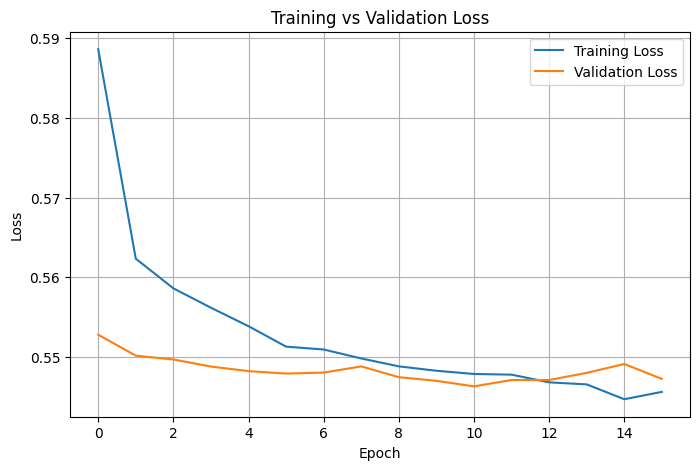

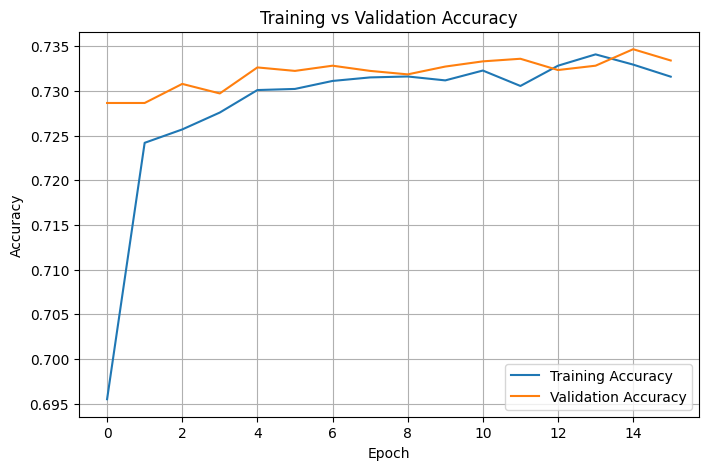

In [18]:
import matplotlib.pyplot as plt

# ==============================
# Training & Validation Loss
# ==============================

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)
plt.show()


# ==============================
# Training & Validation Accuracy
# ==============================

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

In [19]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Neural Network",
        "Final Tuned Neural Network"
    ],
    "Precision": [
        baseline_precision,
        final_precision
    ],
    "Recall": [
        baseline_recall,
        final_recall
    ],
    "F1-score": [
        baseline_f1,
        final_f1
    ]
})

comparison_df

,Model,Precision,Recall,F1-score
0,Baseline Neural Network,0.745830,0.700823,0.722626
1,Final Tuned Neural Network,0.641264,0.850705,0.731284


# Sprint 2 Review

## 1. Objective

The main objective of Sprint 2 was to improve the baseline Neural Network for the Cardio classification task by tuning its architecture and hyperparameters.

Since the dataset is tabular, a Dense Neural Network was selected as the core model architecture.

The main evaluation metric was **F1-score**, with **Recall** also considered important because missing positive cardiac cases is undesirable.

---

## 2. Baseline Model

The baseline model used:

* Architecture: `16 → 8 → 1`
* Learning Rate: `0.001`
* Batch Size: `32`
* Dropout: `0`
* Classification Threshold: `0.50`

### Baseline Test Results

| Metric    |      Score |
| --------- | ---------: |
| Precision |     0.7458 |
| Recall    |     0.7008 |
| F1-score  | **0.7226** |

---

## 3. Hyperparameter Tuning

Several experiments were performed using the validation set.

### Learning Rate

Different learning rates were tested:

`0.01, 0.001, 0.0005, 0.0001`

The best validation F1-score was achieved with:

**Learning Rate = 0.0005**

---

### Architecture

The following architectures were compared:

* `16 → 8`
* `32 → 16`
* `64 → 32 → 16`

The best validation F1-score was achieved by:

**64 → 32 → 16**

with a validation F1-score of approximately **0.7245**.

---

### Dropout

The following dropout rates were tested:

`0.0, 0.1, 0.2, 0.3`

The best validation F1-score was achieved with:

**Dropout = 0.3**

Validation F1-score: **0.7228**

---

### Batch Size

The following batch sizes were tested:

`16, 32, 64`

The best result in this experiment was achieved with:

**Batch Size = 64**

Validation F1-score: **0.7191**

---

### Threshold Tuning

Different classification thresholds were evaluated to improve F1-score and Recall.

The best threshold was:

**Threshold = 0.35**

Validation results:

* Precision: **0.6511**
* Recall: **0.8381**
* F1-score: **0.7329**

---

## 4. Final Tuned Model

The final model used:

| Parameter     | Value               |
| ------------- | ------------------- |
| Architecture  | `64 → 32 → 16 → 1`  |
| Learning Rate | `0.0005`            |
| Dropout       | `0.3`               |
| Batch Size    | `64`                |
| Threshold     | `0.35`              |
| Optimizer     | Adam                |
| Loss          | Binary Crossentropy |

---

## 5. Final Test Results

| Metric    | Baseline | Final Tuned |
| --------- | -------: | ----------: |
| Precision |   0.7458 |      0.6413 |
| Recall    |   0.7008 |  **0.8507** |
| F1-score  |   0.7226 |  **0.7313** |

### Improvement

* **F1-score:** 0.7226 → **0.7313** (+0.0087)
* **Recall:** 0.7008 → **0.8507** (+0.1499)
* Precision decreased from 0.7458 to 0.6413.

The decrease in Precision is expected because lowering the classification threshold increased the number of predicted positive cases.

Overall, the final model achieved a higher F1-score and substantially improved Recall compared with the baseline.

---

## 6. Training Behavior

The training and validation curves did not show a significant gap between training and validation performance.

Therefore, there was **no clear evidence of severe overfitting** during training.

Early Stopping was also used to prevent unnecessary training and restore the best validation weights.

---

# Sprint 2 Retrospective

## What went well?

* A suitable architecture was selected for the tabular dataset.
* Multiple hyperparameters were systematically tested.
* F1-score was used as the primary model-selection metric.
* Recall improved significantly after threshold tuning.
* The final model outperformed the baseline in F1-score.
* Training curves were analyzed to check for overfitting.

## What could be improved?

The tuning process was performed sequentially, where each hyperparameter was optimized while keeping the previously selected settings fixed. This may not guarantee the globally best combination of hyperparameters.

The experiments should also be logged systematically using MLflow to make experiment tracking and comparison easier.

## Concrete Change for Sprint 3

In Sprint 3, we will use **MLflow experiment tracking** to record every experiment's:

* Architecture
* Learning Rate
* Dropout
* Batch Size
* Threshold
* Precision
* Recall
* F1-score

This will make model comparison more reproducible and easier to analyze.

---

# Sprint 2 Conclusion

Sprint 2 successfully improved the baseline Neural Network.

The final model achieved an **F1-score of 0.7313** on the test set compared with **0.7226** for the baseline.

The most significant improvement was in **Recall**, which increased from **70.08% to 85.07%**.

Because Recall is important for identifying positive cardiac cases, the tuned model provides a better balance for the project's objective despite the reduction in Precision.


In [23]:
mlflow.set_experiment("Cardio_Sprint_2")

print("MLflow experiment created successfully!")

2026/09/03 21:27:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/03 21:27:34 INFO mlflow.store.db.utils: Updating database tables
2026/09/03 21:27:37 INFO mlflow.tracking.fluent: Experiment with name 'Cardio_Sprint_2' does not exist. Creating a new experiment.


MLflow experiment created successfully!


In [24]:
import mlflow

experiments = [
    {
        "name": "LR_0.0005",
        "learning_rate": 0.0005,
        "architecture": "16-8",
        "dropout": 0.0,
        "batch_size": 32,
        "f1": 0.721886,
        "recall": 0.701940,
        "precision": 0.742999
    },
    {
        "name": "Architecture_64-32-16",
        "learning_rate": 0.0005,
        "architecture": "64-32-16",
        "dropout": 0.0,
        "batch_size": 32,
        "f1": 0.724479,
        "recall": 0.711346,
        "precision": 0.738105
    },
    {
        "name": "Dropout_0.3",
        "learning_rate": 0.0005,
        "architecture": "64-32-16",
        "dropout": 0.3,
        "batch_size": 32,
        "f1": 0.722755,
        "recall": 0.701156,
        "precision": 0.745727
    },
    {
        "name": "BatchSize_64",
        "learning_rate": 0.0005,
        "architecture": "64-32-16",
        "dropout": 0.3,
        "batch_size": 64,
        "f1": 0.719101,
        "recall": 0.702332,
        "precision": 0.736691
    },
    {
        "name": "Threshold_0.35",
        "learning_rate": 0.0005,
        "architecture": "64-32-16",
        "dropout": 0.3,
        "batch_size": 64,
        "threshold": 0.35,
        "f1": 0.732865,
        "recall": 0.838134,
        "precision": 0.651088
    }
]

for exp in experiments:

    with mlflow.start_run(run_name=exp["name"]):

        mlflow.log_param("learning_rate", exp["learning_rate"])
        mlflow.log_param("architecture", exp["architecture"])
        mlflow.log_param("dropout", exp["dropout"])
        mlflow.log_param("batch_size", exp["batch_size"])

        if "threshold" in exp:
            mlflow.log_param("threshold", exp["threshold"])

        mlflow.log_metric("validation_f1", exp["f1"])
        mlflow.log_metric("validation_recall", exp["recall"])
        mlflow.log_metric("validation_precision", exp["precision"])

print("All experiments logged successfully!")

All experiments logged successfully!


In [25]:
import mlflow

with mlflow.start_run(run_name="Final_Tuned_Model"):

    # Parameters
    mlflow.log_param("architecture", "64-32-16")
    mlflow.log_param("learning_rate", 0.0005)
    mlflow.log_param("dropout", 0.3)
    mlflow.log_param("batch_size", 64)
    mlflow.log_param("threshold", 0.35)

    # Test metrics
    mlflow.log_metric("test_accuracy", final_accuracy)
    mlflow.log_metric("test_precision", final_precision)
    mlflow.log_metric("test_recall", final_recall)
    mlflow.log_metric("test_f1", final_f1)

print("Final model logged successfully!")

Final model logged successfully!
